# Student Math Score Prediction
## Linear Regression Pipeline untuk Prediksi Nilai Matematika Siswa

**Tujuan**: Memprediksi nilai matematika siswa berdasarkan faktor demografis dan latar belakang pendidikan.

**Workflow**:
1. Load & Exploratory Data Analysis (EDA)
2. Feature Engineering & Preprocessing
3. Model Training (Linear Regression)
4. Model Evaluation


---
## 1. Import Libraries


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("Libraries imported!")


pandas: 2.2.2
numpy: 2.0.2
sklearn: 1.6.1
matplotlib: 3.10.0
Libraries imported!


---
## 2. Load Dataset

Dataset: **studentperformance.csv**  
Source: Kaggle - Students Performance in Exams  
1000 baris, 8 kolom


In [28]:
# Load langsung dari folder (pastikan studentperformance.csv
# sudah diupload ke panel kiri Colab terlebih dahulu)
df = pd.read_csv('studentperformance.csv')

print(f"Shape: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")
df.head()


Shape: (1000, 8)
Kolom: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


---
## 3. Exploratory Data Analysis (EDA)


In [29]:
# Cek tipe data dan missing values
print("=== Info Dataset ===")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


=== Info Dataset ===
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [30]:
# Statistik deskriptif untuk kolom numerik
print("=== Statistik Deskriptif ===")
df[['math score', 'reading score', 'writing score']].describe().round(2)


=== Statistik Deskriptif ===


,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


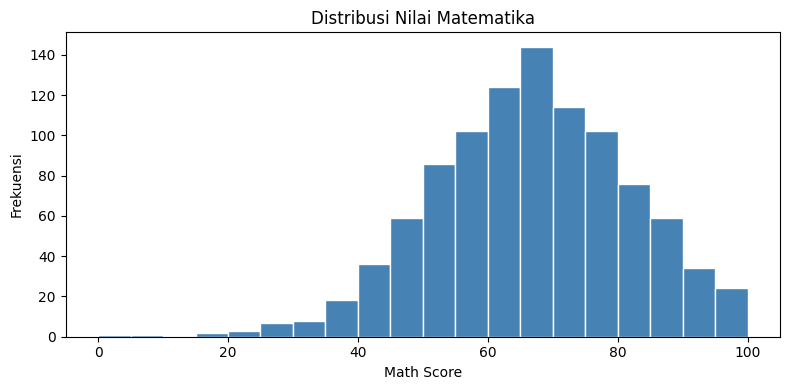

Mean math score: 66.09
Median math score: 66.00


In [31]:
# Distribusi math score
plt.figure(figsize=(8, 4))
plt.hist(df['math score'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribusi Nilai Matematika')
plt.xlabel('Math Score')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

print(f"Mean math score: {df['math score'].mean():.2f}")
print(f"Median math score: {df['math score'].median():.2f}")


In [32]:
# Pengaruh lunch terhadap math score
lunch_stats = (
    df.groupby('lunch')['math score']
    .agg(mean_math='mean', std_math='std', n='count')
    .round(3)
    .sort_values('mean_math', ascending=False)
    .reset_index()
)
print("Rata-rata math score berdasarkan jenis lunch:")
print(lunch_stats)


Rata-rata math score berdasarkan jenis lunch:
          lunch  mean_math  std_math    n
0      standard     70.034    13.654  645
1  free/reduced     58.921    15.160  355


In [33]:
# Korelasi antar nilai
print("Korelasi antar skor:")
print(df[['math score', 'reading score', 'writing score']].corr().round(3))


Korelasi antar skor:
               math score  reading score  writing score
math score          1.000          0.818          0.803
reading score       0.818          1.000          0.955
writing score       0.803          0.955          1.000


---
## 4. Feature Engineering & Preprocessing

- **Categorical features**: gender, race/ethnicity, parental level of education, lunch, test preparation course → OneHotEncoder
- **Numerical features**: reading score, writing score → langsung dipakai (sudah dalam skala yang sama)
- **Target**: math score


In [34]:
categorical_features = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]
numerical_features = ['reading score', 'writing score']

X = df.drop('math score', axis=1)
y = df['math score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]} baris")
print(f"Test size : {X_test.shape[0]} baris")


Train size: 800 baris
Test size : 200 baris


In [35]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

print("\u2705 Preprocessor siap!")
print(f"   Categorical: {categorical_features}")
print(f"   Numerical  : {numerical_features}")


✅ Preprocessor siap!
   Categorical: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
   Numerical  : ['reading score', 'writing score']


---
## 5. Build & Train Model


In [36]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)
print("\u2705 Model training selesai!")


✅ Model training selesai!


---
## 6. Model Evaluation


In [37]:
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MODEL EVALUATION RESULTS")
print(f"R\u00b2 Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")


MODEL EVALUATION RESULTS
R² Score : 0.8804
MAE      : 4.2148
RMSE     : 5.3940


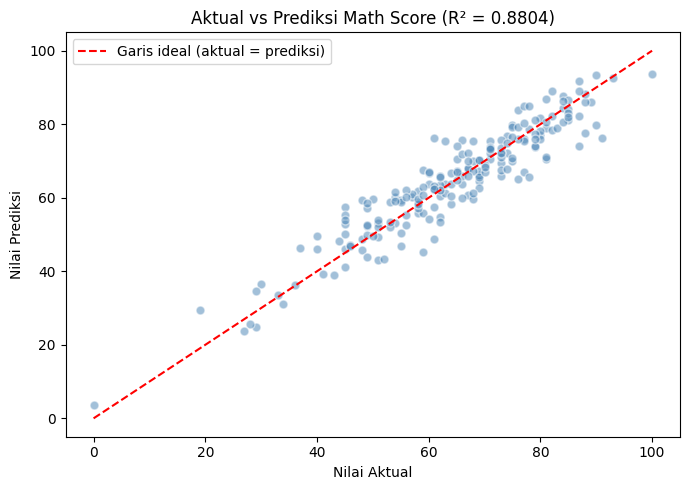

In [38]:
# Plot actual vs predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=40)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=1.5, label='Garis ideal (aktual = prediksi)')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title(f'Aktual vs Prediksi Math Score (R\u00b2 = {r2:.4f})')
plt.legend()
plt.tight_layout()
plt.show()


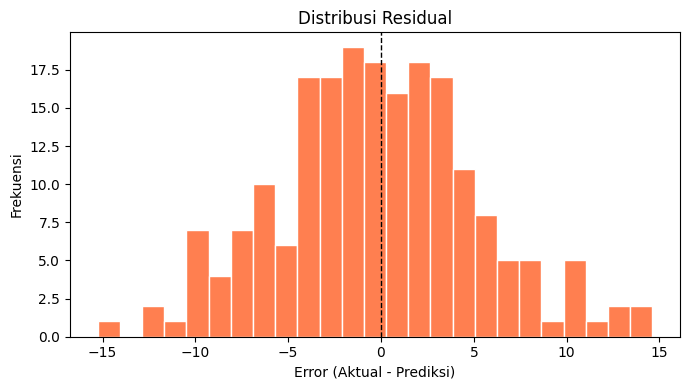

Mean residual: -0.2370
Std residual : 5.4023


In [39]:
# Distribusi residual (error)
residuals = y_test - y_pred

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=25, color='coral', edgecolor='white')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Distribusi Residual')
plt.xlabel('Error (Aktual - Prediksi)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.4f}")
print(f"Std residual : {residuals.std():.4f}")


---
## 7. Kesimpulan

Model Linear Regression berhasil memprediksi nilai matematika siswa dengan:
- **R\u00b2 = 0.8804** — model mampu menjelaskan 88% variasi nilai matematika
- **MAE = 4.2148** — rata-rata selisih prediksi hanya sekitar 4 poin
- **RMSE = 5.3940** — error terbesar masih dalam batas wajar

Fitur **reading score** dan **writing score** adalah prediktor utama, karena keduanya berkorelasi tinggi dengan math score. Faktor tambahan seperti jenis lunch dan persiapan ujian juga berkontribusi meski lebih kecil.
